# FactoryMind AI — NASA C-MAPSS FD001 Exploratory Data Analysis

This notebook begins FactoryMind AI's second ML module: **Remaining Useful Life (RUL) prediction**. It focuses on understanding the sequential degradation data correctly before feature engineering or modeling.

**Scope:** FD001 only. No model is trained, no random row-level split is performed, and no production artifact is created.

## 1. Dataset Loading and Schema

Each row is one operating-cycle observation for one engine unit. Rows belonging to the same unit form an ordered trajectory; they are **not independent machines or independent samples**.

The files are parsed first without assigned names so the observed column count can be validated before applying the conceptual C-MAPSS schema.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("../data/raw")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/raw")

TRAIN_PATH = DATA_DIR / "train_FD001.txt"
TEST_PATH = DATA_DIR / "test_FD001.txt"
RUL_PATH = DATA_DIR / "RUL_FD001.txt"

for path in (TRAIN_PATH, TEST_PATH, RUL_PATH):
    assert path.exists(), f"Required file not found: {path}"

raw_train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None)
raw_test = pd.read_csv(TEST_PATH, sep=r"\s+", header=None)
raw_rul = pd.read_csv(RUL_PATH, sep=r"\s+", header=None)

print("Observed parsed columns:")
print(f"  train: {raw_train.shape[1]}")
print(f"  test:  {raw_test.shape[1]}")
print(f"  RUL:   {raw_rul.shape[1]}")

Observed parsed columns:
  train: 26
  test:  26
  RUL:   1


In [2]:
EXPECTED_FEATURE_COLUMNS = 26
assert raw_train.shape[1] == EXPECTED_FEATURE_COLUMNS
assert raw_test.shape[1] == EXPECTED_FEATURE_COLUMNS
assert raw_rul.shape[1] == 1

columns = (
    ["unit_id", "cycle"]
    + [f"operational_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = raw_train.copy()
test = raw_test.copy()
train.columns = columns
test.columns = columns
provided_test_rul = raw_rul.iloc[:, 0].rename("provided_final_RUL").astype(int)

print(f"Training shape before target derivation: {train.shape}")
print(f"Test shape: {test.shape}")
display(train.head())

Training shape before target derivation: (20631, 26)
Test shape: (13096, 26)


,unit_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0000,518.6700,641.8200,"1,589.7000","1,400.6000",14.6200,21.6100,554.3600,"2,388.0600","9,046.1900",1.3000,47.4700,521.6600,"2,388.0200","8,138.6200",8.4195,0.0300,392,2388,100.0000,39.0600,23.4190
1,1,2,0.0019,-0.0003,100.0000,518.6700,642.1500,"1,591.8200","1,403.1400",14.6200,21.6100,553.7500,"2,388.0400","9,044.0700",1.3000,47.4900,522.2800,"2,388.0700","8,131.4900",8.4318,0.0300,392,2388,100.0000,39.0000,23.4236
2,1,3,-0.0043,0.0003,100.0000,518.6700,642.3500,"1,587.9900","1,404.2000",14.6200,21.6100,554.2600,"2,388.0800","9,052.9400",1.3000,47.2700,522.4200,"2,388.0300","8,133.2300",8.4178,0.0300,390,2388,100.0000,38.9500,23.3442
3,1,4,0.0007,0.0000,100.0000,518.6700,642.3500,"1,582.7900","1,401.8700",14.6200,21.6100,554.4500,"2,388.1100","9,049.4800",1.3000,47.1300,522.8600,"2,388.0800","8,133.8300",8.3682,0.0300,392,2388,100.0000,38.8800,23.3739
4,1,5,-0.0019,-0.0002,100.0000,518.6700,642.3700,"1,582.8500","1,406.2200",14.6200,21.6100,554.0000,"2,388.0600","9,055.1500",1.3000,47.2800,522.1900,"2,388.0400","8,133.8000",8.4294,0.0300,393,2388,100.0000,38.9000,23.4044


## 2. Basic Training Data Audit

Within each unit, cycles begin at 1 and progress chronologically until the simulated failure endpoint. The final training row for a unit is therefore its failure-time observation.

In [3]:
training_audit = pd.Series({
    "observations": len(train),
    "columns": train.shape[1],
    "unique_units": train["unit_id"].nunique(),
    "minimum_cycle": train["cycle"].min(),
    "maximum_cycle": train["cycle"].max(),
    "missing_values": int(train.isna().sum().sum()),
    "duplicate_rows": int(train.duplicated().sum()),
})
display(training_audit.to_frame("value"))

print("Data types:")
display(train.dtypes.value_counts().rename("column_count").to_frame())
print("Observations per engine unit:")
display(train.groupby("unit_id").size().describe().to_frame("observations"))
print("Training descriptive statistics:")
display(train.describe().T)

,value
observations,20631
columns,26
unique_units,100
minimum_cycle,1
maximum_cycle,362
missing_values,0
duplicate_rows,0


Data types:


,column_count
float64,22
int64,4


Observations per engine unit:


,observations
count,100.0000
mean,206.3100
std,46.3427
min,128.0000
25%,177.0000
50%,199.0000
75%,229.2500
max,362.0000


Training descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
unit_id,"20,631.0000",51.5066,29.2276,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,"20,631.0000",108.8079,68.8810,1.0000,52.0000,104.0000,156.0000,362.0000
operational_setting_1,"20,631.0000",-0.0000,0.0022,-0.0087,-0.0015,0.0000,0.0015,0.0087
operational_setting_2,"20,631.0000",0.0000,0.0003,-0.0006,-0.0002,0.0000,0.0003,0.0006
operational_setting_3,"20,631.0000",100.0000,0.0000,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,"20,631.0000",518.6700,0.0000,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,"20,631.0000",642.6809,0.5001,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,"20,631.0000","1,590.5231",6.1311,"1,571.0400","1,586.2600","1,590.1000","1,594.3800","1,616.9100"
sensor_4,"20,631.0000","1,408.9338",9.0006,"1,382.2500","1,402.3600","1,408.0400","1,414.5550","1,441.4900"
sensor_5,"20,631.0000",14.6200,0.0000,14.6200,14.6200,14.6200,14.6200,14.6200


## 3. Derive Training RUL

Training trajectories run to failure, so the final observed cycle is a known failure endpoint. For each training row:

\[
RUL = \text{maximum cycle for the unit} - \text{current cycle}
\]

This derivation is valid for **training only**. Test sequences are deliberately truncated before failure, so their last observed cycle must not be assigned RUL = 0.

In [4]:
training_unit_count_before = train["unit_id"].nunique()
max_cycle_by_unit = train.groupby("unit_id")["cycle"].transform("max")
train["RUL"] = max_cycle_by_unit - train["cycle"]

final_training_rows = train.loc[train.groupby("unit_id")["cycle"].idxmax()]
rul_monotonic = train.groupby("unit_id")["RUL"].apply(lambda values: values.is_monotonic_decreasing)

assert (train["RUL"] >= 0).all()
assert (final_training_rows["RUL"] == 0).all()
assert rul_monotonic.all()
assert train["unit_id"].nunique() == training_unit_count_before

print("RUL validation passed:")
print(f"  Minimum RUL: {train['RUL'].min()}")
print(f"  Units ending at RUL 0: {(final_training_rows['RUL'] == 0).sum()} / {training_unit_count_before}")
print(f"  Chronologically decreasing RUL trajectories: {rul_monotonic.sum()} / {training_unit_count_before}")

RUL validation passed:
  Minimum RUL: 0
  Units ending at RUL 0: 100 / 100
  Chronologically decreasing RUL trajectories: 100 / 100


## 4. Engine Lifetime Analysis

One lifetime value is calculated per engine unit from its maximum training cycle. Representative units are selected mechanically from the shortest lifetime, closest-to-median lifetime, and longest lifetime—without cherry-picking sensor behavior.

,lifetime_cycles
count,100.0000
mean,206.3100
std,46.3427
min,128.0000
25%,177.0000
50%,199.0000
75%,229.2500
max,362.0000


,selection,unit_id,lifetime_cycles
0,shortest-lived,39,128
1,closest to median,26,199
2,longest-lived,69,362


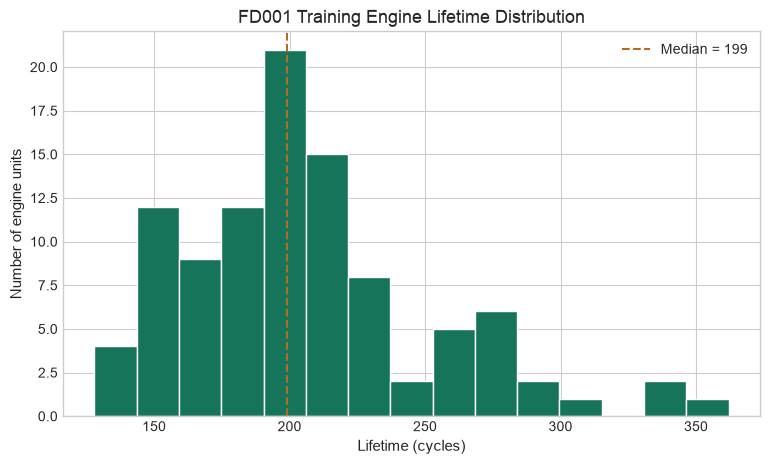

In [5]:
engine_lifetimes = train.groupby("unit_id")["cycle"].max().rename("lifetime_cycles")
lifetime_summary = engine_lifetimes.describe()
display(lifetime_summary.to_frame())

short_unit = int(engine_lifetimes.idxmin())
median_lifetime = engine_lifetimes.median()
median_unit = int((engine_lifetimes - median_lifetime).abs().idxmin())
long_unit = int(engine_lifetimes.idxmax())
representative_units = [short_unit, median_unit, long_unit]
representative_table = engine_lifetimes.loc[representative_units].reset_index()
representative_table["selection"] = ["shortest-lived", "closest to median", "longest-lived"]
display(representative_table[["selection", "unit_id", "lifetime_cycles"]])

fig, ax = plt.subplots()
ax.hist(engine_lifetimes, bins=15, color="#16745b", edgecolor="white")
ax.axvline(median_lifetime, color="#b66b22", linestyle="--", label=f"Median = {median_lifetime:.0f}")
ax.set(title="FD001 Training Engine Lifetime Distribution", xlabel="Lifetime (cycles)", ylabel="Number of engine units")
ax.legend()
plt.show()

Engine lifetimes span a wide range, so unit identity and trajectory length matter. A row from a long-lived unit is not directly interchangeable with a row at the same cycle from a short-lived unit.

## 5. Sensor Audit

All 21 sensors are retained during EDA. Candidate labels below use scale-aware evidence: exact unique-value count, standard deviation, and observed range. They are recommendations for investigation in notebook 07, not automatic deletions.

In [6]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]
sensor_audit = pd.DataFrame({
    "mean": train[sensor_columns].mean(),
    "std": train[sensor_columns].std(),
    "minimum": train[sensor_columns].min(),
    "maximum": train[sensor_columns].max(),
    "variance": train[sensor_columns].var(),
    "unique_values": train[sensor_columns].nunique(),
})
sensor_audit["range"] = sensor_audit["maximum"] - sensor_audit["minimum"]
sensor_audit["relative_range"] = sensor_audit["range"] / sensor_audit["mean"].abs().replace(0, np.nan)
sensor_audit["audit_label"] = np.select(
    [sensor_audit["unique_values"].eq(1), sensor_audit["unique_values"].le(20)],
    ["constant candidate", "near-constant / discrete candidate"],
    default="meaningful observed variation",
)
display(sensor_audit)

,mean,std,minimum,maximum,variance,unique_values,range,relative_range,audit_label
sensor_1,518.6700,0.0000,518.6700,518.6700,0.0000,1,0.0000,0.0000,constant candidate
sensor_2,642.6809,0.5001,641.2100,644.5300,0.2501,310,3.3200,0.0052,meaningful observed variation
sensor_3,"1,590.5231",6.1311,"1,571.0400","1,616.9100",37.5910,3012,45.8700,0.0288,meaningful observed variation
sensor_4,"1,408.9338",9.0006,"1,382.2500","1,441.4900",81.0109,4051,59.2400,0.0420,meaningful observed variation
sensor_5,14.6200,0.0000,14.6200,14.6200,0.0000,1,0.0000,0.0000,constant candidate
sensor_6,21.6098,0.0014,21.6000,21.6100,0.0000,2,0.0100,0.0005,near-constant / discrete candidate
sensor_7,553.3677,0.8851,549.8500,556.0600,0.7834,513,6.2100,0.0112,meaningful observed variation
sensor_8,"2,388.0967",0.0710,"2,387.9000","2,388.5600",0.0050,53,0.6600,0.0003,meaningful observed variation
sensor_9,"9,065.2429",22.0829,"9,021.7300","9,244.5900",487.6536,6403,222.8600,0.0246,meaningful observed variation
sensor_10,1.3000,0.0000,1.3000,1.3000,0.0000,1,0.0000,0.0000,constant candidate


In [7]:
constant_sensors = sensor_audit.index[sensor_audit["unique_values"].eq(1)].tolist()
near_constant_sensors = sensor_audit.index[
    sensor_audit["unique_values"].between(2, 20)
].tolist()
meaningful_sensors = sensor_audit.index[sensor_audit["unique_values"].gt(20)].tolist()

print("Constant candidates:", constant_sensors)
print("Near-constant / low-unique candidates:", near_constant_sensors)
print("Sensors with meaningful observed variation:", meaningful_sensors)

Constant candidates: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Near-constant / low-unique candidates: ['sensor_6', 'sensor_17']
Sensors with meaningful observed variation: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_20', 'sensor_21']


Sensor 17 has few integer-valued levels but still varies materially and later shows a relationship with RUL. It should therefore not be removed solely because its unique-value count is low. Sensor 6, by contrast, changes only across two very close values and is a stronger near-constant candidate.

## 6. Operating Settings

FD001 represents one nominal operating condition, but the observed settings must still be inspected. Small numerical variation can reflect simulation/control noise rather than genuinely distinct operating regimes.

,count,mean,std,min,25%,50%,75%,max,unique_values,range
operational_setting_1,"20,631.0000",-0.0000,0.0022,-0.0087,-0.0015,0.0000,0.0015,0.0087,158,0.0174
operational_setting_2,"20,631.0000",0.0000,0.0003,-0.0006,-0.0002,0.0000,0.0003,0.0006,13,0.0012
operational_setting_3,"20,631.0000",100.0000,0.0000,100.0000,100.0000,100.0000,100.0000,100.0000,1,0.0000


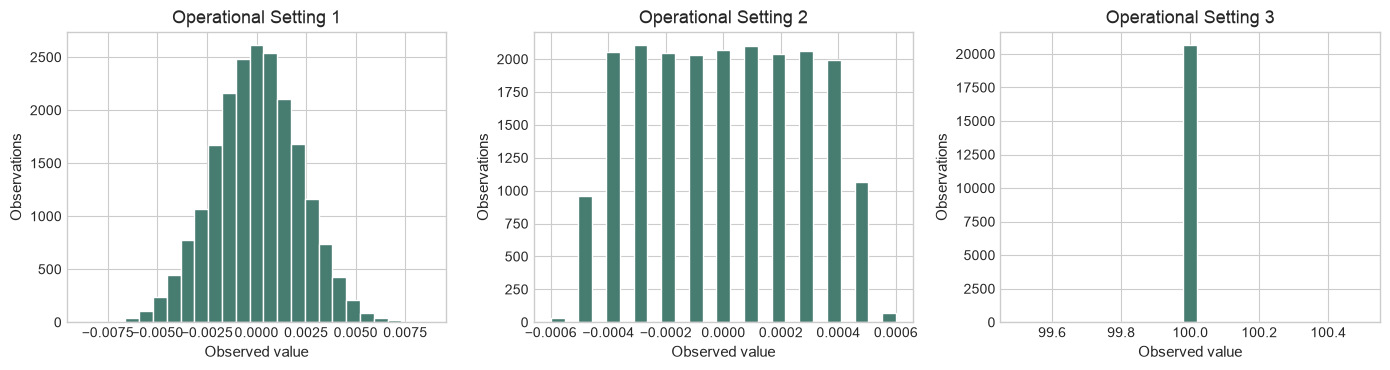

In [8]:
setting_columns = [f"operational_setting_{i}" for i in range(1, 4)]
settings_audit = train[setting_columns].describe().T
settings_audit["unique_values"] = train[setting_columns].nunique()
settings_audit["range"] = settings_audit["max"] - settings_audit["min"]
display(settings_audit)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, setting in zip(axes, setting_columns):
    ax.hist(train[setting], bins=25, color="#477c70", edgecolor="white")
    ax.set(title=setting.replace("_", " ").title(), xlabel="Observed value", ylabel="Observations")
plt.tight_layout()
plt.show()

Operational settings 1 and 2 vary only within narrow ranges, while setting 3 is exactly constant at 100. This supports treating FD001 as effectively single-condition. It simplifies this subset, but the conclusion must **not** be generalized to FD002–FD004, which contain different operating-condition and fault-mode combinations.

## 7. Sensor Correlation Structure

The correlation view excludes exact constant sensors because their correlations are undefined. Correlation is exploratory: highly correlated features may still behave differently over time, and removal decisions belong in feature engineering.

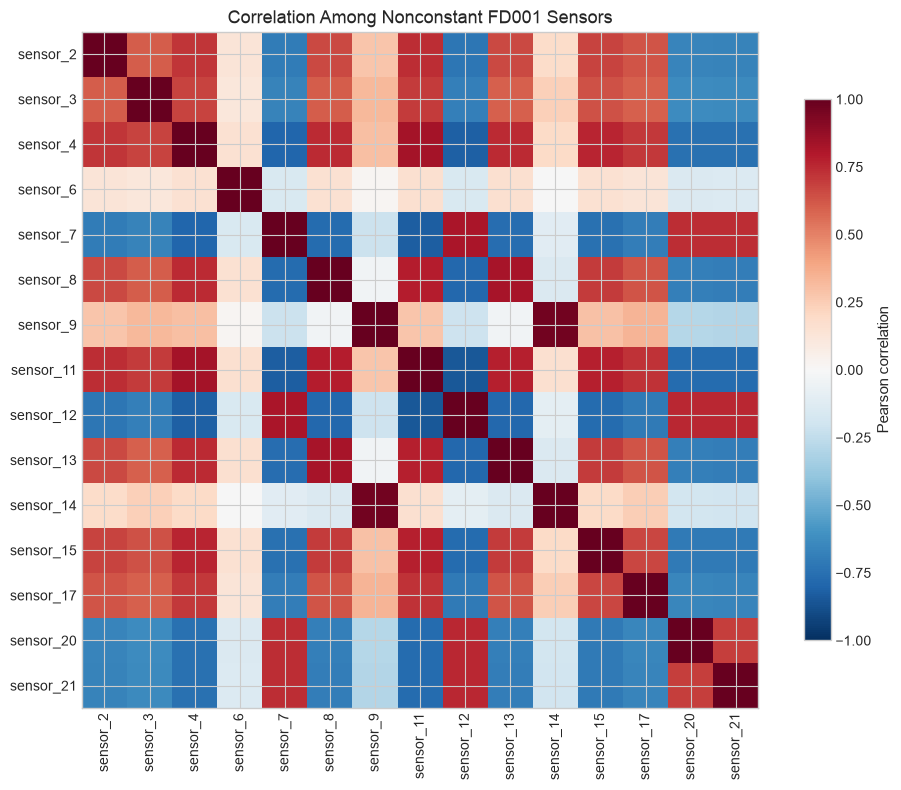

,sensor_a,sensor_b,correlation,absolute_correlation
100,sensor_9,sensor_14,0.9632,0.9632
113,sensor_11,sensor_12,-0.8469,0.8469
37,sensor_4,sensor_11,0.8301,0.8301
84,sensor_8,sensor_13,0.8261,0.8261
67,sensor_7,sensor_11,-0.8228,0.8228
38,sensor_4,sensor_12,-0.8156,0.8156
68,sensor_7,sensor_12,0.8127,0.8127
34,sensor_4,sensor_7,-0.7931,0.7931
129,sensor_12,sensor_13,-0.7884,0.7884
83,sensor_8,sensor_12,-0.7865,0.7865


In [9]:
correlation_sensors = [sensor for sensor in sensor_columns if sensor not in constant_sensors]
sensor_corr = train[correlation_sensors].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(sensor_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_sensors)), correlation_sensors, rotation=90)
ax.set_yticks(range(len(correlation_sensors)), correlation_sensors)
ax.set_title("Correlation Among Nonconstant FD001 Sensors")
fig.colorbar(image, ax=ax, label="Pearson correlation", shrink=0.8)
plt.tight_layout()
plt.show()

upper_triangle = sensor_corr.where(np.triu(np.ones(sensor_corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "sensor_a", "level_1": "sensor_b"})
)
high_corr_pairs["absolute_correlation"] = high_corr_pairs["correlation"].abs()
display(high_corr_pairs.query("absolute_correlation >= 0.75").sort_values("absolute_correlation", ascending=False))

## 8. Representative Engine Degradation

The same lifetime-based units selected earlier are used for every plot. Sensors 11, 12, and 4 are selected because the global audit shows substantial variation and strong raw association with RUL. Raw values are shown without smoothing.

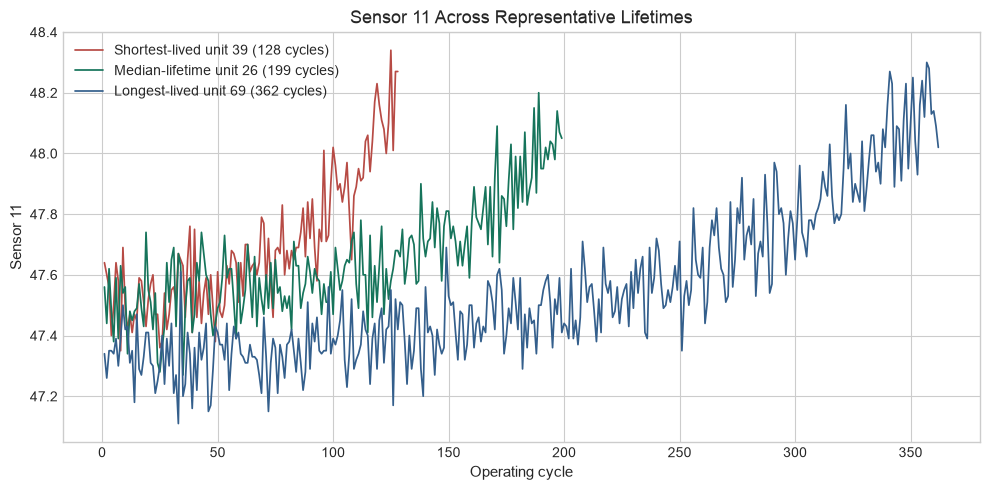

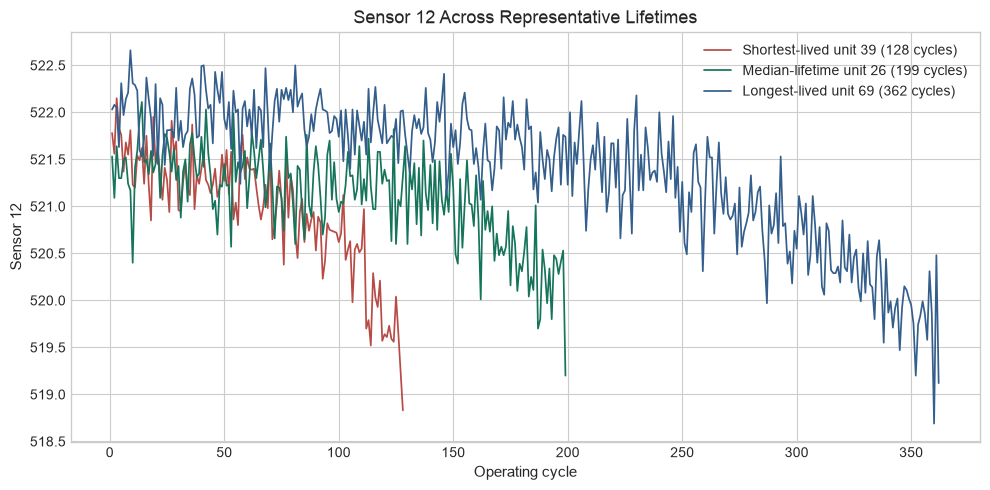

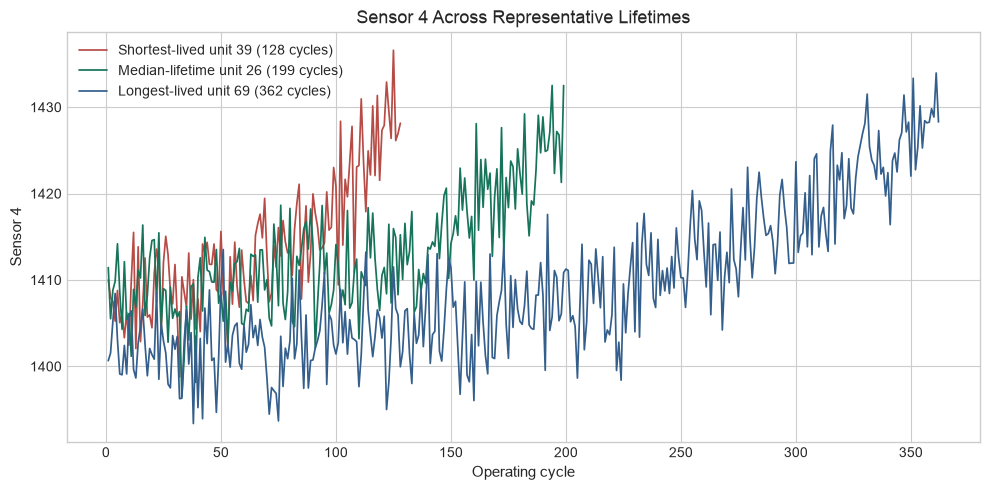

In [10]:
selected_degradation_sensors = ["sensor_11", "sensor_12", "sensor_4"]
selection_names = dict(zip(representative_units, ["Shortest-lived", "Median-lifetime", "Longest-lived"]))
colors = ["#b74b45", "#16745b", "#345f8c"]

for sensor in selected_degradation_sensors:
    fig, ax = plt.subplots(figsize=(10, 5))
    for unit_id, color in zip(representative_units, colors):
        unit_data = train.loc[train["unit_id"].eq(unit_id)]
        ax.plot(unit_data["cycle"], unit_data[sensor], color=color, linewidth=1.25,
                label=f"{selection_names[unit_id]} unit {unit_id} ({len(unit_data)} cycles)")
    ax.set(title=f"{sensor.replace('_', ' ').title()} Across Representative Lifetimes",
           xlabel="Operating cycle", ylabel=sensor.replace("_", " ").title())
    ax.legend()
    plt.tight_layout()
    plt.show()

The representative trajectories show directional degradation, but substantial cycle-level noise remains. Sensor 11 and sensor 4 generally rise toward failure, whereas sensor 12 generally declines. The timing and smoothness differ across units, so raw degradation is visible but not perfectly separable from noise; backward-looking rolling and change features deserve investigation.

## 9. Sensor Relationship With RUL

Pearson correlation measures a global linear row-level association. It does not capture nonlinear deterioration, unit-specific baselines, late-life acceleration, or temporal dynamics.

,correlation_with_RUL,absolute_correlation
sensor_11,-0.6962,0.6962
sensor_4,-0.6789,0.6789
sensor_12,0.6720,0.6720
sensor_7,0.6572,0.6572
sensor_15,-0.6427,0.6427
sensor_21,0.6357,0.6357
sensor_20,0.6294,0.6294
sensor_2,-0.6065,0.6065
sensor_17,-0.6062,0.6062
sensor_3,-0.5845,0.5845


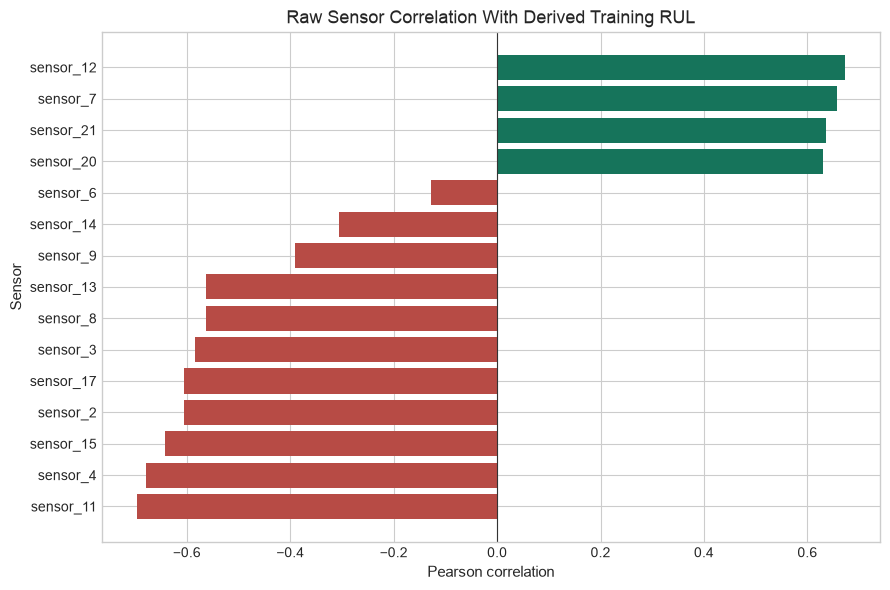

In [11]:
sensor_rul_correlation = train[correlation_sensors + ["RUL"]].corr()["RUL"].drop("RUL")
sensor_rul_rank = sensor_rul_correlation.rename("correlation_with_RUL").to_frame()
sensor_rul_rank["absolute_correlation"] = sensor_rul_rank["correlation_with_RUL"].abs()
sensor_rul_rank = sensor_rul_rank.sort_values("absolute_correlation", ascending=False)
display(sensor_rul_rank)

fig, ax = plt.subplots(figsize=(9, 6))
ordered = sensor_rul_rank.sort_values("correlation_with_RUL")
bar_colors = ["#b74b45" if value < 0 else "#16745b" for value in ordered["correlation_with_RUL"]]
ax.barh(ordered.index, ordered["correlation_with_RUL"], color=bar_colors)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(title="Raw Sensor Correlation With Derived Training RUL", xlabel="Pearson correlation", ylabel="Sensor")
plt.tight_layout()
plt.show()

Sensors 11, 4, 12, 7, 15, and 21 show the strongest absolute raw relationships. The sign is operationally meaningful: negative correlation means the sensor tends to increase as failure approaches, while positive correlation means it tends to decrease. Low correlation does not establish uselessness—trends, rolling summaries, rates of change, and degradation trajectories can contain information absent from a raw row-level coefficient.

## 10. Raw RUL Distribution

Long trajectories contribute many early-life rows with large RUL. In regression, these observations can dominate the loss even though precise long-horizon remaining life may be difficult—and less operationally important—to distinguish.

,RUL
count,"20,631.0000"
mean,107.8079
std,68.8810
min,0.0000
25%,51.0000
50%,103.0000
75%,155.0000
max,361.0000


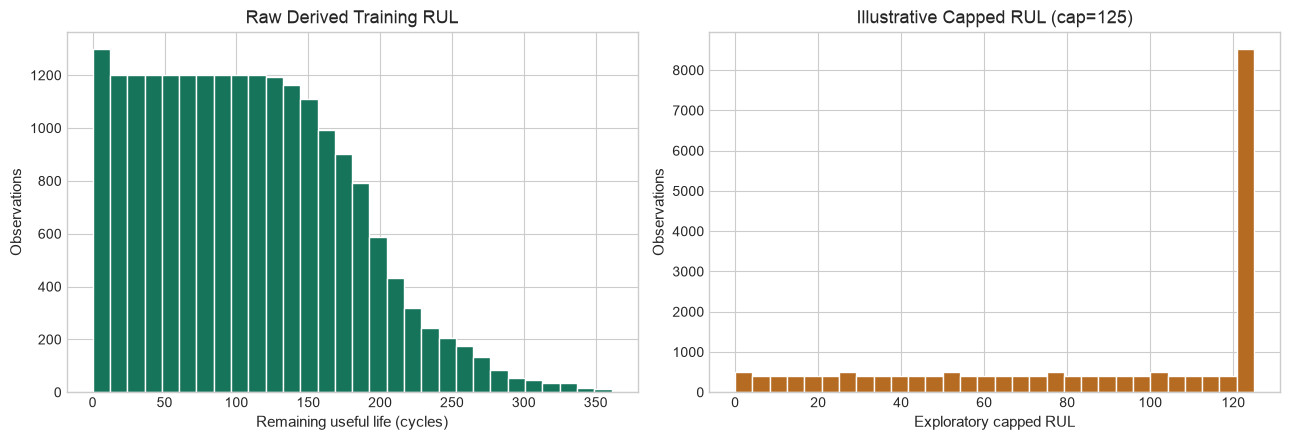

In [12]:
display(train["RUL"].describe().to_frame())

illustrative_cap = 125
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(train["RUL"], bins=30, color="#16745b", edgecolor="white")
axes[0].set(title="Raw Derived Training RUL", xlabel="Remaining useful life (cycles)", ylabel="Observations")
axes[1].hist(train["RUL"].clip(upper=illustrative_cap), bins=30, color="#b66b22", edgecolor="white")
axes[1].set(title=f"Illustrative Capped RUL (cap={illustrative_cap})", xlabel="Exploratory capped RUL", ylabel="Observations")
plt.tight_layout()
plt.show()

The cap of 125 above is **illustrative, not selected for production**. Piecewise RUL is common conceptually because early healthy stages may be practically indistinguishable. Notebook 07 should compare and justify target strategies rather than adopting a cap solely because it is common in prior work.

## 11. Test Set Structure

Training trajectories run to failure. Test trajectories stop earlier, so the last observed test row is a prediction point—not a failure row—and cannot be assigned RUL = 0.

In [13]:
test_audit = pd.Series({
    "observations": len(test),
    "columns": test.shape[1],
    "unique_units": test["unit_id"].nunique(),
    "minimum_cycle": test["cycle"].min(),
    "maximum_cycle": test["cycle"].max(),
    "missing_values": int(test.isna().sum().sum()),
    "duplicate_rows": int(test.duplicated().sum()),
})
display(test_audit.to_frame("value"))
print("Observed test sequence lengths:")
display(test.groupby("unit_id").size().describe().to_frame("observations"))

,value
observations,13096
columns,26
unique_units,100
minimum_cycle,1
maximum_cycle,303
missing_values,0
duplicate_rows,0


Observed test sequence lengths:


,observations
count,100.0000
mean,130.9600
std,53.5935
min,31.0000
25%,88.7500
50%,133.5000
75%,164.2500
max,303.0000


## 12. Provided Test RUL Labels

`RUL_FD001.txt` contains remaining life **after each test unit's final observed cycle**, ordered by unit. These values are held-out evaluation ground truth and must never become model inputs.

In [14]:
test_unit_ids = np.sort(test["unit_id"].unique())
assert len(provided_test_rul) == len(test_unit_ids)

last_test_cycle = test.groupby("unit_id")["cycle"].max().reindex(test_unit_ids)
test_endpoints = pd.DataFrame({
    "unit_id": test_unit_ids,
    "last_observed_cycle": last_test_cycle.to_numpy(),
    "provided_final_RUL": provided_test_rul.to_numpy(),
})
test_endpoints["implied_failure_cycle"] = (
    test_endpoints["last_observed_cycle"] + test_endpoints["provided_final_RUL"]
)

print(f"Provided labels: {len(provided_test_rul)}")
print(f"Unique test units: {len(test_unit_ids)}")
display(test_endpoints.head(10))

Provided labels: 100
Unique test units: 100


,unit_id,last_observed_cycle,provided_final_RUL,implied_failure_cycle
0,1,31,112,143
1,2,49,98,147
2,3,126,69,195
3,4,106,82,188
4,5,98,91,189
5,6,105,93,198
6,7,160,91,251
7,8,166,95,261
8,9,55,111,166
9,10,192,96,288


## 13. Full Test RUL Construction for Evaluation Only

Once the held-out endpoint label is known, the true RUL for an earlier observed test cycle can be reconstructed as:

\[
\text{last observed cycle} + \text{provided final RUL} - \text{current cycle}
\]

This construction is useful for retrospective evaluation only. In real inference, future lifetime and the provided label are unavailable.

In [15]:
test_evaluation = test.merge(test_endpoints, on="unit_id", validate="many_to_one")
test_evaluation["true_test_RUL"] = (
    test_evaluation["last_observed_cycle"]
    + test_evaluation["provided_final_RUL"]
    - test_evaluation["cycle"]
)
final_test_rows = test_evaluation.loc[test_evaluation.groupby("unit_id")["cycle"].idxmax()]

assert (final_test_rows["true_test_RUL"].to_numpy() == final_test_rows["provided_final_RUL"].to_numpy()).all()
assert (test_evaluation["true_test_RUL"] >= 0).all()

display(test_evaluation[["unit_id", "cycle", "last_observed_cycle", "provided_final_RUL", "true_test_RUL"]].head())
print("Final-cycle evaluation RUL matches the provided label for every test unit.")

,unit_id,cycle,last_observed_cycle,provided_final_RUL,true_test_RUL
0,1,1,31,112,142
1,1,2,31,112,141
2,1,3,31,112,140
3,1,4,31,112,139
4,1,5,31,112,138


Final-cycle evaluation RUL matches the provided label for every test unit.


## RUL Leakage Risks

1. **Random row-level splitting is invalid.** Cycles from one engine would leak the same unit's condition and trajectory into multiple partitions.
2. **Future measurements are unavailable at inference.** A current-cycle feature cannot use later sensor readings.
3. **Rolling features must be backward-looking.** Centered windows or forward shifts leak future condition.
4. **Scaling must be learned from training data only.** Validation and test distributions cannot influence fitted preprocessing.
5. **Final engine lifetime is not an input feature.** It is only known retrospectively for run-to-failure training trajectories.
6. **Provided test RUL is evaluation ground truth.** It cannot be used as a predictor or in fitted transformations.
7. **Chronological causality must be preserved.** Every engineered feature at cycle \(t\) may depend only on information available through cycle \(t\).
8. **Later validation must split by unit.** Entire engine trajectories should be assigned to training or validation, never randomly mixed by rows.

## 15. Potential Feature-Engineering Directions

Notebook 07 should investigate a compact, interpretable set of features:

- remove exact constants and carefully evaluate near-constant candidates;
- compare raw and explicitly justified capped RUL targets;
- fit sensor normalization using training units only;
- create backward-looking rolling means and standard deviations;
- add carefully chosen lags and first differences/rates of change;
- retain cycle as a degradation-stage signal while avoiding final-lifetime leakage;
- consider a small number of physically or empirically justified sensor interactions;
- evaluate all choices with unit-level validation splits.

The objective is to capture trajectory shape without producing hundreds of arbitrary or future-looking features.

## 16. Final Validation

In [16]:
validation_results = pd.Series({
    "training_RUL_never_negative": bool((train["RUL"] >= 0).all()),
    "every_training_unit_ends_at_RUL_zero": bool((final_training_rows["RUL"] == 0).all()),
    "training_unit_count_preserved": train["unit_id"].nunique() == training_unit_count_before,
    "provided_labels_match_test_units": len(provided_test_rul) == test["unit_id"].nunique(),
    "final_test_RUL_matches_provided_label": bool((final_test_rows["true_test_RUL"] == final_test_rows["provided_final_RUL"]).all()),
    "random_row_split_performed": False,
    "ML_model_trained": False,
})
display(validation_results.to_frame("result"))
assert validation_results.drop(["random_row_split_performed", "ML_model_trained"]).all()
assert not validation_results["random_row_split_performed"]
assert not validation_results["ML_model_trained"]

,result
training_RUL_never_negative,True
every_training_unit_ends_at_RUL_zero,True
training_unit_count_preserved,True
provided_labels_match_test_units,True
final_test_RUL_matches_provided_label,True
random_row_split_performed,False
ML_model_trained,False


## C-MAPSS EDA Conclusions

- **Training data:** 20,631 cycle observations from 100 engine units.
- **Lifetime variation:** 128 minimum, 199 median, and 362 maximum cycles, showing substantial differences among unit trajectories.
- **Raw training RUL:** 0 to 361 cycles, with a median of 103 cycles.
- **Constant sensors:** sensors 1, 5, 10, 16, 18, and 19. Sensor 6 is an especially narrow two-value near-constant candidate. Sensor 17 has only 13 integer levels but retains a strong RUL relationship and should not be discarded on unique count alone.
- **Strongest raw RUL relationships:** sensors 11 and 4 are negatively correlated with RUL; sensors 12 and 7 are positively correlated. Sensors 15 and 21 are also prominent. These are global linear associations, not complete measures of sequential utility.
- **Operating conditions:** settings 1 and 2 vary narrowly and setting 3 is constant, consistent with FD001's effectively single-condition design. This conclusion does not transfer automatically to FD002–FD004.
- **Representative degradation:** lifetime-selected units show noisy but visible upward behavior in sensors 11 and 4 and downward behavior in sensor 12 as failure approaches.
- **Target strategy:** the large healthy-life region makes a capped/piecewise RUL target worth evaluating, but the illustrative cap shown here is not a final decision.
- **Test data:** 13,096 observations from 100 truncated engine sequences. The 100 provided endpoint RUL labels align one-to-one with the ordered test units.
- **Leakage control:** later work must use unit-level validation, backward-looking features, training-only preprocessing, and must keep final lifetime and test labels out of predictors.

**Recommended next step:** create `notebooks/07_rul_feature_engineering.ipynb` to compare defensible target formulations and build a causal, unit-aware feature pipeline. Notebook 07 is not created here.